In [337]:
import warnings
warnings.filterwarnings("ignore")

In [338]:
import pandas as pd

# Load your dataset
df = pd.read_excel("enaura_invoice_dataset.xlsx")

In [339]:
df

,Invoice ID,Salon Name,City,Invoice Date,Due Date,Payment Date,Product Category,Invoice Amount,Client Type,Repeat Client,Payment Method,Discount Given,Payment Status,Days Late
0,INV001,Salon_018,Delhi,2024-04-05,2024-04-20,2024-04-29,Color Mask,6304.08,B2B,No,UPI,0%,Paid Late,9
1,INV002,Salon_006,Delhi,2024-04-17,2024-05-02,2024-05-09,Color Mask,7982.56,B2B,No,Bank Transfer,5%,Paid Late,7
2,INV003,Salon_038,Hyderabad,2024-01-25,2024-02-09,2024-02-19,Hair Repair Shampoo,10103.76,B2B,Yes,Bank Transfer,5%,Paid Late,10
3,INV004,Salon_007,Chennai,2024-07-04,2024-07-19,2024-07-22,Argan Oil,14055.89,B2B,Yes,Cash,10%,Paid Late,3
4,INV005,Salon_008,Kolkata,2024-02-18,2024-03-04,2024-03-07,Color Mask,18281.78,B2B,No,Bank Transfer,10%,Paid Late,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,INV096,Salon_010,Kolkata,2024-04-20,2024-05-05,2024-05-10,Serum,17960.40,B2B,No,Cash,5%,Paid Late,5
96,INV097,Salon_033,Hyderabad,2024-01-10,2024-01-25,2024-02-03,Color Mask,13698.85,B2B,No,Bank Transfer,5%,Paid Late,9
97,INV098,Salon_035,Ahmedabad,2024-06-11,2024-06-26,2024-07-02,Color Mask,10658.15,B2B,No,Bank Transfer,10%,Paid Late,6
98,INV099,Salon_016,Kolkata,2024-04-25,2024-05-10,2024-05-14,Argan Oil,16170.58,B2B,No,Cash,10%,Paid Late,4


In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Invoice ID        100 non-null    object        
 1   Salon Name        100 non-null    object        
 2   City              100 non-null    object        
 3   Invoice Date      100 non-null    datetime64[ns]
 4   Due Date          100 non-null    datetime64[ns]
 5   Payment Date      100 non-null    datetime64[ns]
 6   Product Category  100 non-null    object        
 7   Invoice Amount    100 non-null    float64       
 8   Client Type       100 non-null    object        
 9   Repeat Client     100 non-null    object        
 10  Payment Method    100 non-null    object        
 11  Discount Given    100 non-null    object        
 12  Payment Status    100 non-null    object        
 13  Days Late         100 non-null    int64         
dtypes: datetime64[ns](3), float

In [341]:

# Extract invoice month
df["Invoice Month"] = df["Invoice Date"].dt.to_period("M").astype(str)

# Convert Discount Given from text ("5%") to numeric
df["Discount (%)"] = df["Discount Given"].str.replace("%", "").astype(int)


In [342]:
df.head()

,Invoice ID,Salon Name,City,Invoice Date,Due Date,Payment Date,Product Category,Invoice Amount,Client Type,Repeat Client,Payment Method,Discount Given,Payment Status,Days Late,Invoice Month,Discount (%)
0,INV001,Salon_018,Delhi,2024-04-05,2024-04-20,2024-04-29,Color Mask,6304.08,B2B,No,UPI,0%,Paid Late,9,2024-04,0
1,INV002,Salon_006,Delhi,2024-04-17,2024-05-02,2024-05-09,Color Mask,7982.56,B2B,No,Bank Transfer,5%,Paid Late,7,2024-04,5
2,INV003,Salon_038,Hyderabad,2024-01-25,2024-02-09,2024-02-19,Hair Repair Shampoo,10103.76,B2B,Yes,Bank Transfer,5%,Paid Late,10,2024-01,5
3,INV004,Salon_007,Chennai,2024-07-04,2024-07-19,2024-07-22,Argan Oil,14055.89,B2B,Yes,Cash,10%,Paid Late,3,2024-07,10
4,INV005,Salon_008,Kolkata,2024-02-18,2024-03-04,2024-03-07,Color Mask,18281.78,B2B,No,Bank Transfer,10%,Paid Late,3,2024-02,10


In [343]:
# Define a function to bucket days late
def delay_bucket(days):
    if days == 0:
        return "On Time"
    elif 1 <= days <= 3:
        return "1-3 days late"
    elif 4 <= days <= 7:
        return "4-7 days late"
    elif 8 <= days <= 14:
        return "8-14 days late"
    else:
        return "15+ days late"

# Create Payment Delay Bucket
df["Payment Delay Bucket"] = df["Days Late"].apply(delay_bucket)

# Preview cleaned data
print(df[["Invoice ID", "Invoice Month", "Discount (%)", "Days Late", "Payment Delay Bucket"]].head())


  Invoice ID Invoice Month  Discount (%)  Days Late Payment Delay Bucket
0     INV001       2024-04             0          9       8-14 days late
1     INV002       2024-04             5          7        4-7 days late
2     INV003       2024-01             5         10       8-14 days late
3     INV004       2024-07            10          3        1-3 days late
4     INV005       2024-02            10          3        1-3 days late


In [344]:
df.head()

,Invoice ID,Salon Name,City,Invoice Date,Due Date,Payment Date,Product Category,Invoice Amount,Client Type,Repeat Client,Payment Method,Discount Given,Payment Status,Days Late,Invoice Month,Discount (%),Payment Delay Bucket
0,INV001,Salon_018,Delhi,2024-04-05,2024-04-20,2024-04-29,Color Mask,6304.08,B2B,No,UPI,0%,Paid Late,9,2024-04,0,8-14 days late
1,INV002,Salon_006,Delhi,2024-04-17,2024-05-02,2024-05-09,Color Mask,7982.56,B2B,No,Bank Transfer,5%,Paid Late,7,2024-04,5,4-7 days late
2,INV003,Salon_038,Hyderabad,2024-01-25,2024-02-09,2024-02-19,Hair Repair Shampoo,10103.76,B2B,Yes,Bank Transfer,5%,Paid Late,10,2024-01,5,8-14 days late
3,INV004,Salon_007,Chennai,2024-07-04,2024-07-19,2024-07-22,Argan Oil,14055.89,B2B,Yes,Cash,10%,Paid Late,3,2024-07,10,1-3 days late
4,INV005,Salon_008,Kolkata,2024-02-18,2024-03-04,2024-03-07,Color Mask,18281.78,B2B,No,Bank Transfer,10%,Paid Late,3,2024-02,10,1-3 days late


# Payment Status by City

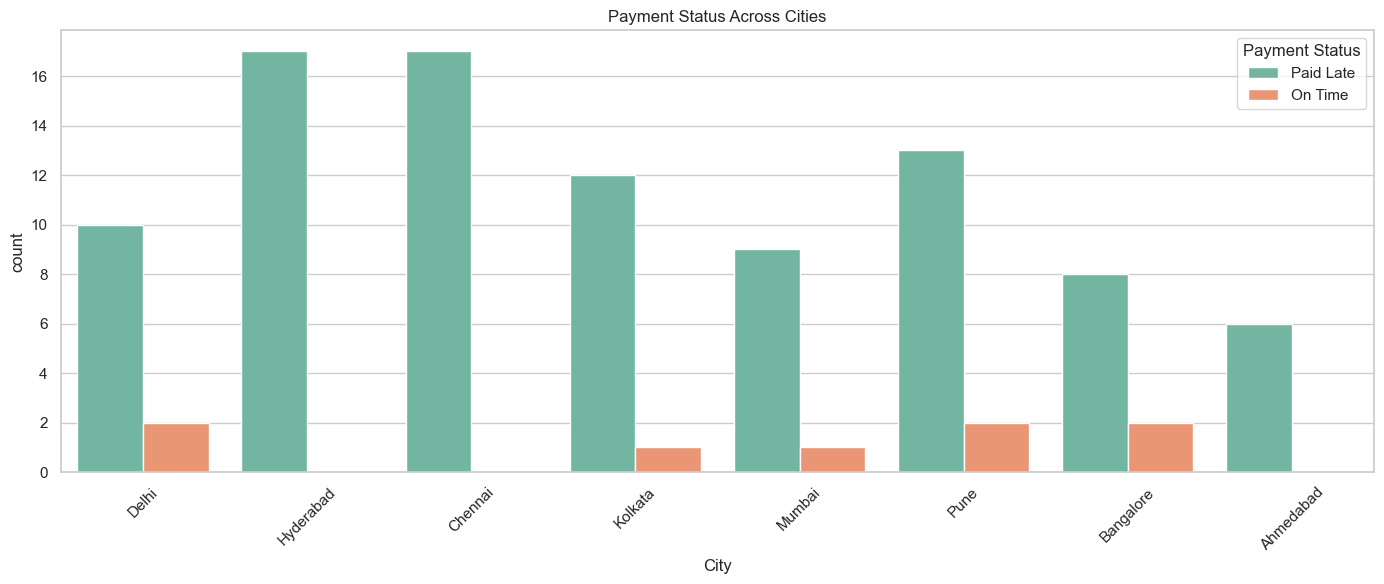

In [346]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Countplot: Payment Status by City
sns.countplot(data=df, x="City", hue="Payment Status", palette="Set2")
plt.title("Payment Status Across Cities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Payment Delay over Time (Monthly Average)


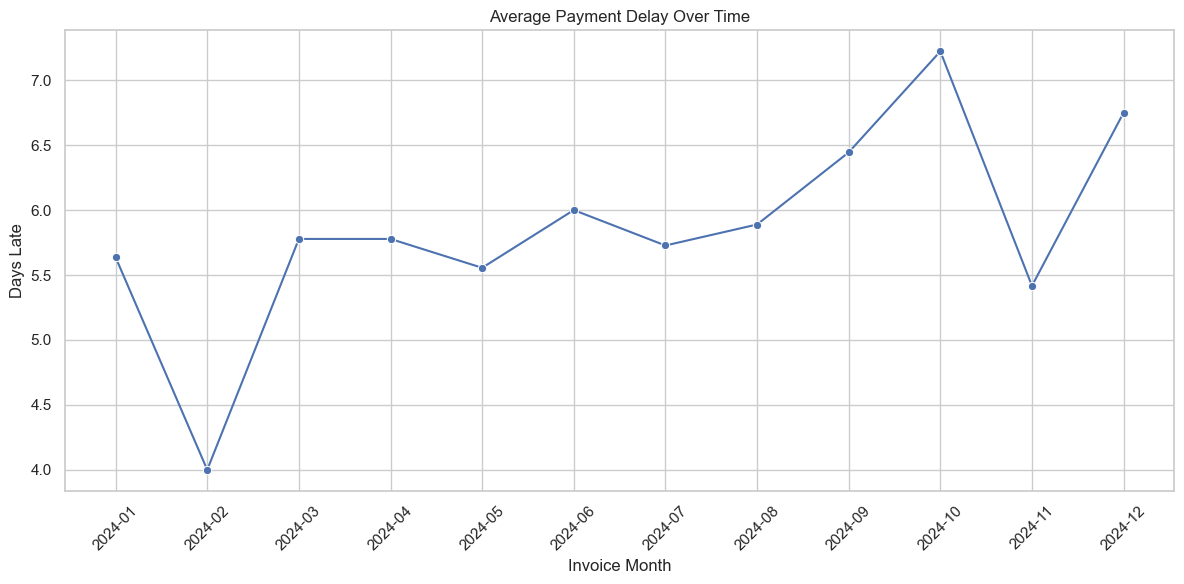

In [348]:
# Group by invoice month and calculate average delay
monthly_delay = df.groupby("Invoice Month")["Days Late"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_delay, x="Invoice Month", y="Days Late", marker="o")
plt.title("Average Payment Delay Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Average Days Late per City

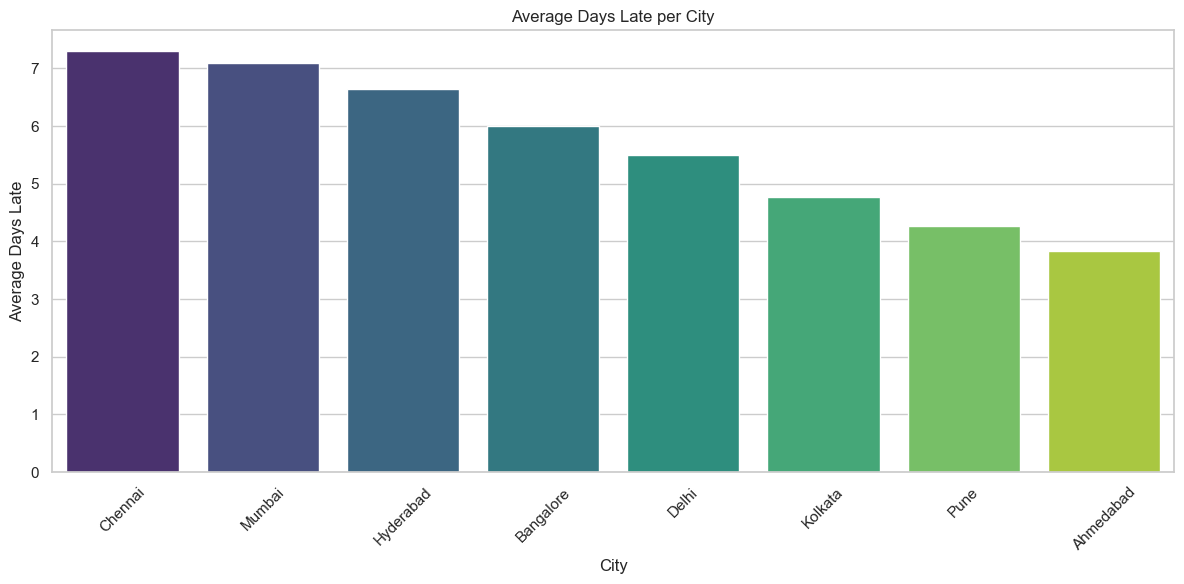

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average days late per city
avg_days_late_city = df.groupby("City")["Days Late"].mean().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_days_late_city.index, y=avg_days_late_city.values, palette="viridis")
plt.title("Average Days Late per City")
plt.ylabel("Average Days Late")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Total Revenue Trends Over Months

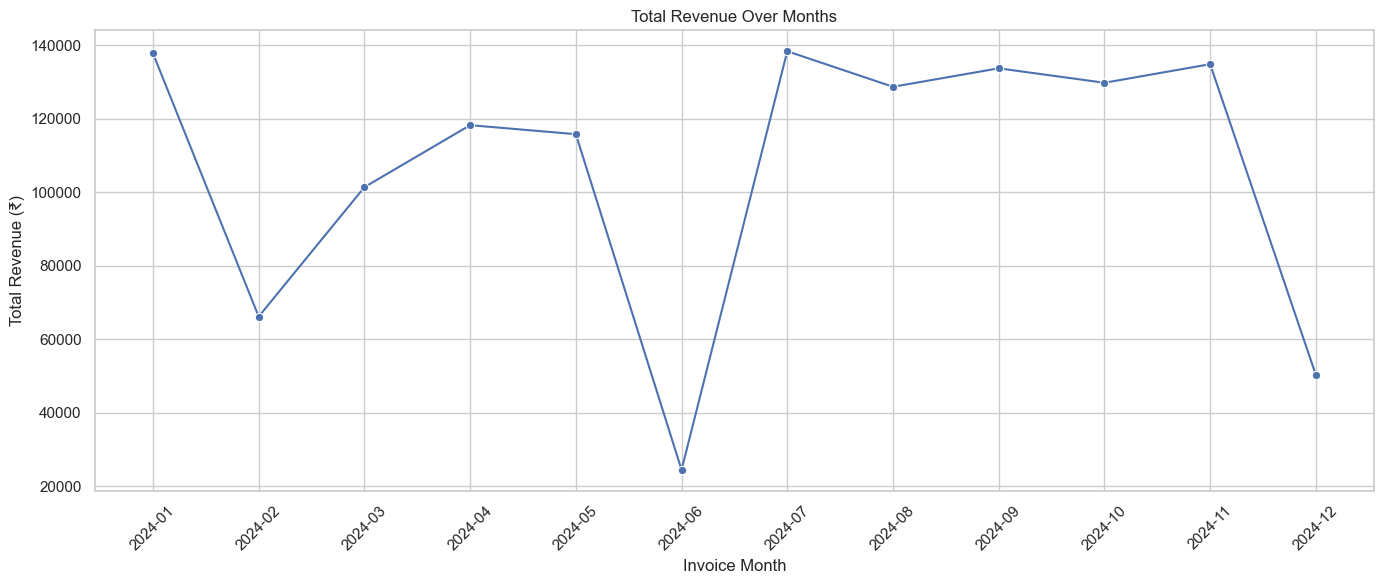

In [352]:
# Calculate total revenue per invoice month
monthly_revenue = df.groupby("Invoice Month")["Invoice Amount"].sum().sort_index()

# Plotting
plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o")
plt.title("Total Revenue Over Months")
plt.ylabel("Total Revenue (₹)")
plt.xlabel("Invoice Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Repeat vs New customer

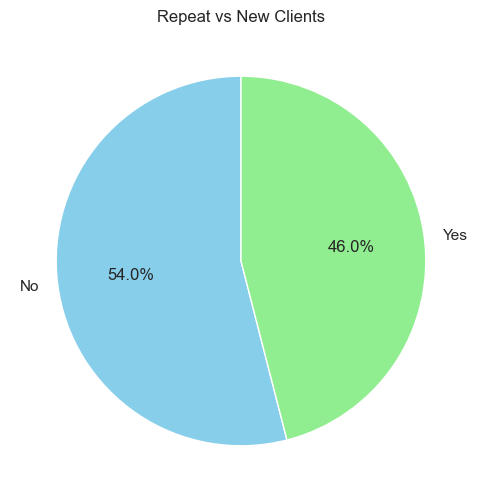

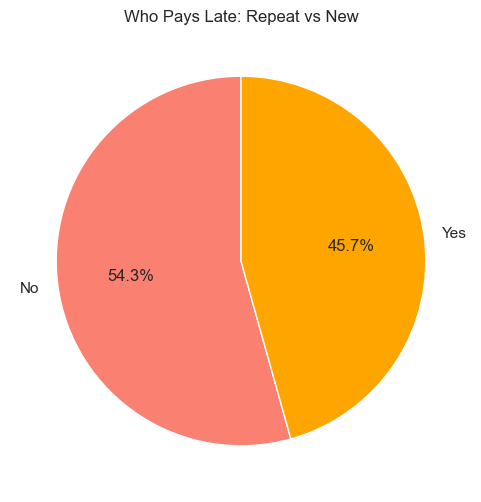

In [354]:
# Pie Chart for client type
repeat_counts = df["Repeat Client"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(repeat_counts, labels=repeat_counts.index, autopct='%1.1f%%', startangle=90, colors=["skyblue", "lightgreen"])
plt.title("Repeat vs New Clients")
plt.show()

# Pie Chart for how often they pay late
late_pay = df[df["Days Late"] > 0]["Repeat Client"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(late_pay, labels=late_pay.index, autopct='%1.1f%%', startangle=90, colors=["salmon", "orange"])
plt.title("Who Pays Late: Repeat vs New")
plt.show()


# Average Days Late by Payment Method

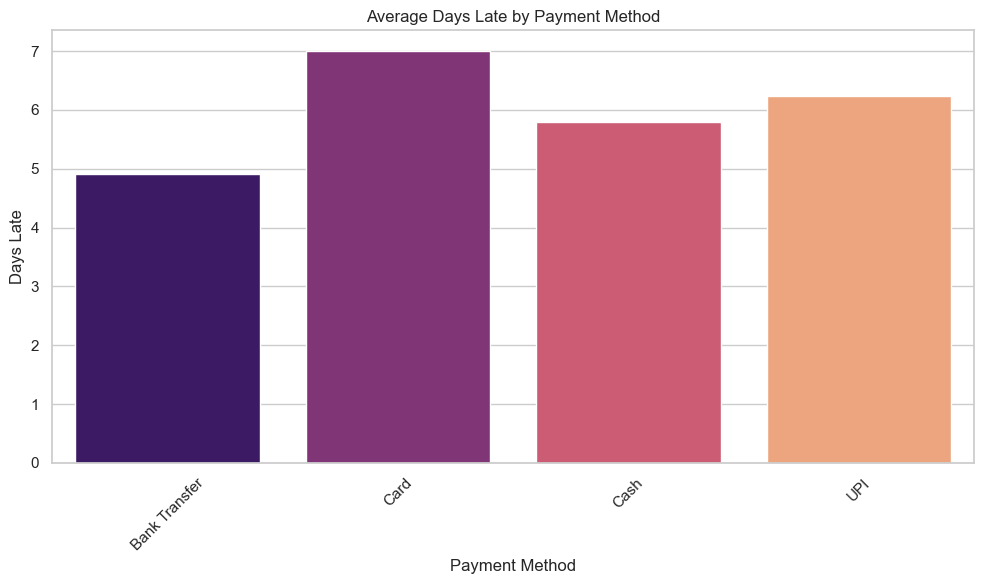

In [356]:
avg_delay_method = df.groupby("Payment Method")["Days Late"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_delay_method, x="Payment Method", y="Days Late", palette="magma")
plt.title("Average Days Late by Payment Method")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Late Payments by Product Category

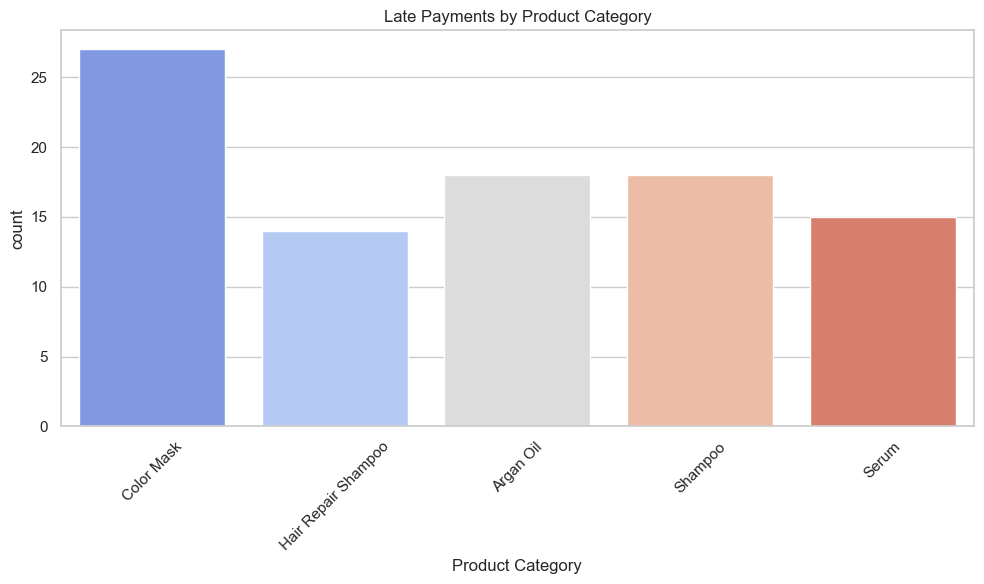

In [358]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df[df["Days Late"] > 0], x="Product Category", palette="coolwarm")
plt.title("Late Payments by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Predictive Modeling

In [360]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [361]:

# Encode target variable
df['Payment Status'] = df['Payment Status'].map({'Paid Late': 1, 'On Time': 0})

df.head(10)

,Invoice ID,Salon Name,City,Invoice Date,Due Date,Payment Date,Product Category,Invoice Amount,Client Type,Repeat Client,Payment Method,Discount Given,Payment Status,Days Late,Invoice Month,Discount (%),Payment Delay Bucket
0,INV001,Salon_018,Delhi,2024-04-05,2024-04-20,2024-04-29,Color Mask,6304.08,B2B,No,UPI,0%,1,9,2024-04,0,8-14 days late
1,INV002,Salon_006,Delhi,2024-04-17,2024-05-02,2024-05-09,Color Mask,7982.56,B2B,No,Bank Transfer,5%,1,7,2024-04,5,4-7 days late
2,INV003,Salon_038,Hyderabad,2024-01-25,2024-02-09,2024-02-19,Hair Repair Shampoo,10103.76,B2B,Yes,Bank Transfer,5%,1,10,2024-01,5,8-14 days late
3,INV004,Salon_007,Chennai,2024-07-04,2024-07-19,2024-07-22,Argan Oil,14055.89,B2B,Yes,Cash,10%,1,3,2024-07,10,1-3 days late
4,INV005,Salon_008,Kolkata,2024-02-18,2024-03-04,2024-03-07,Color Mask,18281.78,B2B,No,Bank Transfer,10%,1,3,2024-02,10,1-3 days late
5,INV006,Salon_005,Mumbai,2024-11-08,2024-11-23,2024-12-03,Shampoo,17829.77,B2B,Yes,Cash,5%,1,10,2024-11,5,8-14 days late
6,INV007,Salon_030,Pune,2024-03-12,2024-03-27,2024-03-30,Argan Oil,15527.30,B2B,Yes,Bank Transfer,10%,1,3,2024-03,10,1-3 days late
7,INV008,Salon_047,Delhi,2024-03-15,2024-03-30,2024-04-03,Color Mask,8294.23,B2B,No,UPI,0%,1,4,2024-03,0,4-7 days late
8,INV009,Salon_003,Pune,2024-07-09,2024-07-24,2024-07-24,Color Mask,18145.51,B2B,No,Bank Transfer,10%,0,0,2024-07,10,On Time
9,INV010,Salon_032,Kolkata,2024-11-15,2024-11-30,2024-12-01,Serum,8699.41,B2B,No,Cash,10%,1,1,2024-11,10,1-3 days late


In [362]:
# Encode categorical features
cat_cols = ['City', 'Product Category', 'Repeat Client', 'Payment Method']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

df_encoded.head()

,Invoice ID,Salon Name,Invoice Date,Due Date,Payment Date,Invoice Amount,Client Type,Discount Given,Payment Status,Days Late,...,City_Mumbai,City_Pune,Product Category_Color Mask,Product Category_Hair Repair Shampoo,Product Category_Serum,Product Category_Shampoo,Repeat Client_Yes,Payment Method_Card,Payment Method_Cash,Payment Method_UPI
0,INV001,Salon_018,2024-04-05,2024-04-20,2024-04-29,6304.08,B2B,0%,1,9,...,0,0,1,0,0,0,0,0,0,1
1,INV002,Salon_006,2024-04-17,2024-05-02,2024-05-09,7982.56,B2B,5%,1,7,...,0,0,1,0,0,0,0,0,0,0
2,INV003,Salon_038,2024-01-25,2024-02-09,2024-02-19,10103.76,B2B,5%,1,10,...,0,0,0,1,0,0,1,0,0,0
3,INV004,Salon_007,2024-07-04,2024-07-19,2024-07-22,14055.89,B2B,10%,1,3,...,0,0,0,0,0,0,1,0,1,0
4,INV005,Salon_008,2024-02-18,2024-03-04,2024-03-07,18281.78,B2B,10%,1,3,...,0,0,1,0,0,0,0,0,0,0


In [363]:
# Select features and target
X = df_encoded.drop(columns=['Invoice ID', 'Salon Name', 'Invoice Date', 'Invoice Month', 'Client Type', 'Due Date', 'Payment Date', 'Payment Status', 'Discount Given','Payment Delay Bucket'])
y = df_encoded['Payment Status']

# Step 1: Check for missing values in y
print(y.isnull().sum())

# Step 2: Drop rows where y is NaN
X = X[~y.isnull()]
y = y[~y.isnull()]

0


In [364]:
X.head()

,Invoice Amount,Days Late,Discount (%),City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Product Category_Color Mask,Product Category_Hair Repair Shampoo,Product Category_Serum,Product Category_Shampoo,Repeat Client_Yes,Payment Method_Card,Payment Method_Cash,Payment Method_UPI
0,6304.08,9,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
1,7982.56,7,5,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
2,10103.76,10,5,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
3,14055.89,3,10,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0
4,18281.78,3,10,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0


In [365]:
# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [366]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model training
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      0.95      0.95        19

    accuracy                           0.90        20
   macro avg       0.47      0.47      0.47        20
weighted avg       0.90      0.90      0.90        20

Confusion Matrix:
 [[ 0  1]
 [ 1 18]]


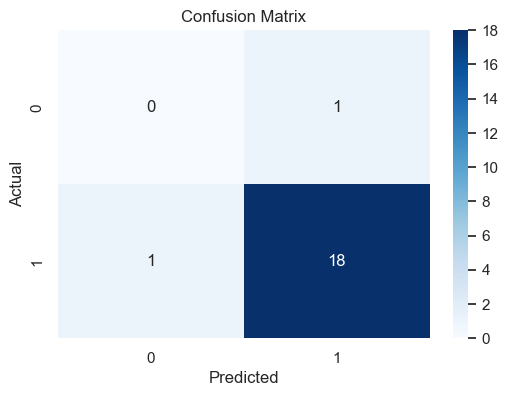

In [367]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: Confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [368]:
import pandas as pd

# Create a new entry based on your input
new_data = pd.DataFrame([{
    'Invoice Amount': 5000,
    'Days Late': 10,
    'Discount (%)': 5,
    'City_Bangalore': 1,  # Bangalore is the city, so it's 1
    'City_Chennai': 0,
    'City_Delhi': 0,
    'City_Hyderabad': 0,
    'City_Kolkata': 0,
    'City_Mumbai': 0,
    'City_Pune': 0,
    'Product Category_Color Mask': 0,
    'Product Category_Hair Repair Shampoo': 0,
    'Product Category_Serum': 0,
    'Product Category_Shampoo': 1,  # Shampoo is the product, so it's 1
    'Repeat Client_Yes': 1,  # Repeat client is Yes, so it's 1
    'Payment Method_Card': 1,  # Payment method is Card, so it's 1
    'Payment Method_Cash': 0,
    'Payment Method_UPI': 0
}], columns=[
    'Invoice Amount', 'Days Late', 'Discount (%)',
    'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai', 'City_Pune',
    'Product Category_Color Mask', 'Product Category_Hair Repair Shampoo', 'Product Category_Serum', 'Product Category_Shampoo',
    'Repeat Client_Yes', 'Payment Method_Card', 'Payment Method_Cash', 'Payment Method_UPI'
])

new_data


,Invoice Amount,Days Late,Discount (%),City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Product Category_Color Mask,Product Category_Hair Repair Shampoo,Product Category_Serum,Product Category_Shampoo,Repeat Client_Yes,Payment Method_Card,Payment Method_Cash,Payment Method_UPI
0,5000,10,5,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0


In [369]:
# Assuming the model is already trained and ready for prediction

# Predict the class for the new data
prediction = model.predict(new_data)

# Print the prediction
print("Predicted Payment Status:", prediction[0])


Predicted Payment Status: 0
